# GSE250346 (Dataset 01) — load & explore TMA5 SpatialData

GEO human lung Xenium TMA data ([GSE250346](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE250346)).

This notebook loads the companion **TMA5.zarr** SpatialData store and inspects its elements (images, labels, shapes, transcript points, cell table). For AnnData/h5ad exploration see [`00_load_and_explore.ipynb`](00_load_and_explore.ipynb).

> **Note:** `TMA5.zarr` uses Zarr v3 (SpatialData 0.7.2). Requires Python ≥3.11 and spatialdata ≥0.7.2.

**Kernel:** `spatialdata`

In [23]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scanpy as sc
import spatialdata as sd
import spatialdata_plot  # registers .pl accessor


ZARR_PATH = Path("/home/mmaycon/KIDS26-Team18/data/Dataset_01/raw_data/TMA5_subset.zarr")
#H5AD_PATH = "/home/mmaycon/KIDS26-Team18/data/Dataset_01/processed_data/outdated/GSE250346_slim.h5ad"

assert ZARR_PATH.is_dir(), f"Missing zarr store: {ZARR_PATH}"
#assert H5AD_PATH.is_file(), f"Missing h5ad: {H5AD_PATH}"
print(f"Zarr path: {ZARR_PATH}")
#print(f"h5ad path: {H5AD_PATH}")

Zarr path: /home/mmaycon/KIDS26-Team18/data/Dataset_01/raw_data/TMA5_subset.zarr


In [24]:
sdata = sd.read_zarr(ZARR_PATH)
print(sdata)

SpatialData object, with associated Zarr store: /home/mmaycon/KIDS26-Team18/data/Dataset_01/raw_data/TMA5_subset.zarr
├── Images
│     └── 'morphology_focus': DataTree[cyx] (4, 5176, 5176), (4, 2588, 2588), (4, 1294, 1294)
├── Labels
│     ├── 'cell_labels': DataTree[yx] (5176, 5176), (2588, 2588), (1294, 1294)
│     └── 'nucleus_labels': DataTree[yx] (5176, 5176), (2588, 2588), (1294, 1294)
├── Points
│     └── 'transcripts': DataFrame with shape: (<Delayed>, 11) (3D points)
├── Shapes
│     ├── 'cell_boundaries': GeoDataFrame shape: (112861, 1) (2D shapes)
│     ├── 'cell_circles': GeoDataFrame shape: (112617, 2) (2D shapes)
│     └── 'nucleus_boundaries': GeoDataFrame shape: (111907, 1) (2D shapes)
└── Tables
      └── 'table': AnnData (112617, 343)
with coordinate systems:
    ▸ 'global', with elements:
        morphology_focus (Images), cell_labels (Labels), nucleus_labels (Labels), transcripts (Points), cell_boundaries (Shapes), cell_circles (Shapes), nucleus_boundaries (Shapes)


In [25]:
print("Images:", list(sdata.images.keys()))
morph = sdata.images["morphology_focus"]
print("  morphology_focus scales:", list(morph.children.keys()))
for scale in ["scale0", "scale1"]:
    ds = morph[scale].dataset
    print(f"    {scale}: {dict(ds.sizes)}")

print("\nLabels:", list(sdata.labels.keys()))
for key in sdata.labels:
    print(f"  {key} scales:", list(sdata.labels[key].children.keys()))

print("\nShapes:", list(sdata.shapes.keys()))
for key in sdata.shapes:
    print(f"  {key}: {len(sdata.shapes[key]):,} geometries")

print("\nPoints:", list(sdata.points.keys()))
transcripts = sdata.points["transcripts"]
print(f"  transcripts: {len(transcripts):,} rows, columns: {list(transcripts.columns)}")

print("\nTables:", list(sdata.tables.keys()))

Images: ['morphology_focus']
  morphology_focus scales: ['scale0', 'scale1', 'scale2']
    scale0: {'c': 4, 'y': 5176, 'x': 5176}
    scale1: {'c': 4, 'y': 2588, 'x': 2588}

Labels: ['cell_labels', 'nucleus_labels']
  cell_labels scales: ['scale0', 'scale1', 'scale2']
  nucleus_labels scales: ['scale0', 'scale1', 'scale2']

Shapes: ['cell_boundaries', 'cell_circles', 'nucleus_boundaries']
  cell_boundaries: 112,861 geometries
  cell_circles: 112,617 geometries
  nucleus_boundaries: 111,907 geometries

Points: ['transcripts']
  transcripts: 10,391,514 rows, columns: ['x', 'y', 'z', 'feature_name', 'cell_id', 'codeword_index', 'fov_name', 'nucleus_distance', 'qv', 'transcript_id', 'overlaps_nucleus']

Tables: ['table']


In [26]:
table = sdata.tables["table"]
print(table)
print(f"\nobs columns ({len(table.obs.columns)}): {table.obs.columns.tolist()}")
print(f"obsm keys: {list(table.obsm.keys())}")
table.obs.head()

AnnData object with n_obs × n_vars = 112617 × 343
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'

obs columns (13): ['cell_id', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'region', 'z_level', 'nucleus_count', 'cell_labels']
obsm keys: ['spatial']


,cell_id,transcript_counts,control_probe_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,nucleus_area,region,z_level,nucleus_count,cell_labels
cell_id,,,,,,,,,,,,,
aggillcc-1,aggillcc-1,26,0,0,0,0,26,27.545313,20.365469,cell_circles,0.0,1.0,17374
aggimmlo-1,aggimmlo-1,37,0,0,0,0,37,37.208751,24.068282,cell_circles,0.0,1.0,17375
aggipjhh-1,aggipjhh-1,68,0,0,0,0,68,48.678439,28.267814,cell_circles,0.0,1.0,17376
aggjaola-1,aggjaola-1,38,0,0,0,0,38,34.499376,17.385157,cell_circles,0.0,1.0,17377
aggjccib-1,aggjccib-1,48,0,0,0,0,48,44.207970,25.784220,cell_circles,0.0,1.0,17378


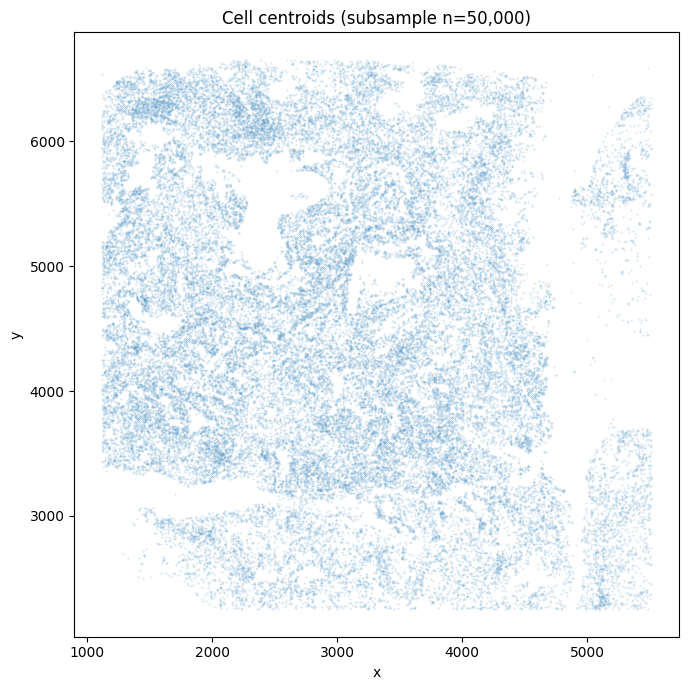

In [27]:
# Centroid scatter (subsample for speed)
coords = table.obsm["spatial"]
rng = np.random.default_rng(0)
n_sub = min(50_000, coords.shape[0])
idx = rng.choice(coords.shape[0], size=n_sub, replace=False)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(coords[idx, 0], coords[idx, 1], s=0.1, alpha=0.3, rasterized=True)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Cell centroids (subsample n={n_sub:,})")
plt.tight_layout()
plt.show()

Cells in crop: 112,617


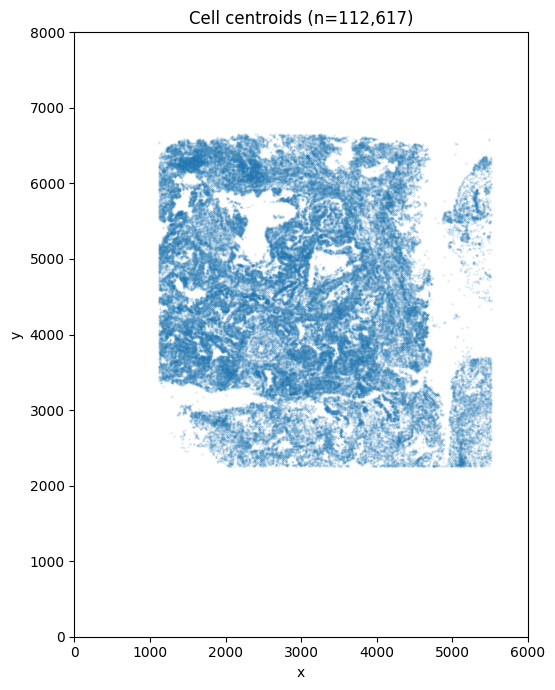

In [28]:
# Crop coordinates to bounding box
xmin = 0
xmax = 6000
ymin = 0
ymax = 8000

coords = table.obsm["spatial"]

mask = (

    (coords[:, 0] >= xmin) &

    (coords[:, 0] <= xmax) &

    (coords[:, 1] >= ymin) &

    (coords[:, 1] <= ymax)

)

# Final cropped AnnData

adata = table[mask].copy()

print(f"Cells in crop: {adata.n_obs:,}")

# Plot centroids

coords = adata.obsm["spatial"]

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(

    coords[:, 0],

    coords[:, 1],

    s=0.1,

    alpha=0.3,

    rasterized=True,

)

ax.set_aspect("equal")

ax.set_xlim(xmin, xmax)

ax.set_ylim(ymin, ymax)

ax.set_xlabel("x")

ax.set_ylabel("y")

ax.set_title(f"Cell centroids (n={adata.n_obs:,})")

plt.tight_layout()

plt.show()

## Cross-reference with h5ad

The cropped `adata` above is joined to `GSE250346_slim.h5ad` on `cell_id`, bringing in all h5ad `.obs` columns (e.g. `sample_id`, `final_CT`, `TMA_core`, UMAP). The full h5ad has 1,630,319 cells; the zarr table has 628,860 (TMA5 core only). See [`01_load_and_explore.ipynb`](01_load_and_explore.ipynb) for full h5ad exploration.

In [29]:
# Join all h5ad .obs columns onto the cropped SpatialData table (by cell_id)
'''adata_ref = sc.read_h5ad(H5AD_PATH, backed="r")
h5ad_obs = adata_ref.obs.drop_duplicates(subset="cell_id", keep="first").copy()

obs_sdata = adata.obs.copy()
if obs_sdata.index.name == "cell_id":
    obs_sdata = obs_sdata.reset_index(drop=True)

h5ad_cols = [c for c in h5ad_obs.columns if c != "cell_id"]
adata.obs = obs_sdata.merge(h5ad_obs[["cell_id", *h5ad_cols]], on="cell_id", how="left")

n_matched = adata.obs["sample_id"].notna().sum()
print(f"Merged h5ad obs: {len(h5ad_cols)} columns added")
print(f"Matched cells: {n_matched:,} / {adata.n_obs:,}")
print(f"Total obs columns: {len(adata.obs.columns)}")
print(adata.obs.columns.tolist())'''

'adata_ref = sc.read_h5ad(H5AD_PATH, backed="r")\nh5ad_obs = adata_ref.obs.drop_duplicates(subset="cell_id", keep="first").copy()\n\nobs_sdata = adata.obs.copy()\nif obs_sdata.index.name == "cell_id":\n    obs_sdata = obs_sdata.reset_index(drop=True)\n\nh5ad_cols = [c for c in h5ad_obs.columns if c != "cell_id"]\nadata.obs = obs_sdata.merge(h5ad_obs[["cell_id", *h5ad_cols]], on="cell_id", how="left")\n\nn_matched = adata.obs["sample_id"].notna().sum()\nprint(f"Merged h5ad obs: {len(h5ad_cols)} columns added")\nprint(f"Matched cells: {n_matched:,} / {adata.n_obs:,}")\nprint(f"Total obs columns: {len(adata.obs.columns)}")\nprint(adata.obs.columns.tolist())'

In [30]:
#adata.obs = adata.obs.drop(columns=["UMAP1", "UMAP2"])

In [31]:
#adata.obs["final_CT"].value_counts(dropna=False)

In [32]:
adata.obs.rename(
    columns={
        "transcript_counts": "nCount",
        "total_counts": "nFeature"
    },
    inplace=True
)

In [33]:
# Sanity check: .X should hold integer transcript counts
x = adata.X.toarray() if hasattr(adata.X, "toarray") else np.asarray(adata.X)
assert x.min() >= 0, f"Expected nonnegative counts, got min={x.min()}"
assert np.allclose(x.sum(axis=1), adata.obs["nCount"], rtol=1e-4), "X row sums must match nCount"
print(f"X holds integer transcript counts (min={x.min():.0f}, max={x.max():.0f})")
print(f"Row-sum check vs nCount: OK ({adata.n_obs:,} cells)")

X holds integer transcript counts (min=0, max=131)
Row-sum check vs nCount: OK (112,617 cells)


In [34]:
#print("Published final_CT counts in this sample:")
#display(adata.obs["final_CT"].value_counts().head(15))

In [35]:
adata.obs["sample_id"].value_counts(dropna=False)


KeyError: 'sample_id'

In [36]:
adata.write_h5ad("/home/mmaycon/KIDS26-Team18/data/Dataset_01/processed_data/one_sample.h5ad")